In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
data = pd.read_csv(r'E:\Dataset\Iris.csv')
print(data.head())

X = data[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']].values
y = data['Species'].map({'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}).values

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.3, random_state=42
)

In [4]:
class LDA_MultiClass:
 def fit(self, X, y):
     self.classes = np.unique(y)
     n_features = X.shape[1]
    
     mean_overall = np.mean(X, axis=0)
     Sw = np.zeros((n_features, n_features))
     Sb = np.zeros((n_features, n_features))
     for c in self.classes:
         X_c = X[y == c]
         mean_c = np.mean(X_c, axis=0)
         Sw += np.cov(X_c, rowvar=False) * (X_c.shape[0] - 1)
         n_c = X_c.shape[0]
         mean_diff = (mean_c - mean_overall).reshape(n_features, 1)
         Sb += n_c * mean_diff.dot(mean_diff.T)
     eigvals, eigvecs = np.linalg.eig(np.linalg.inv(Sw).dot(Sb))
     idxs = np.argsort(abs(eigvals))[::-1]
     self.W = eigvecs[:, idxs[:len(self.classes)-1]]
     # Store projected training data
     X_proj_train = X.dot(self.W)
     # Store class means in projected space
     self.class_means = []
     for c in self.classes:
         self.class_means.append(np.mean(X_proj_train[y == c], axis=0)         )
 def predict(self, X):
     X_proj = X.dot(self.W)
     y_pred = []
     for x in X_proj:
         distances = [np.linalg.norm(x - m) for m in self.class_means]
         y_pred.append(self.classes[np.argmin(distances)])
     return np.array(y_pred)

In [5]:
lda_multi = LDA_MultiClass()
lda_multi.fit(X_train, y_train)
y_pred = lda_multi.predict(X_test)
print("Multi-Class LDA Accuracy:", accuracy_score(y_test, y_pred))

Multi-Class LDA Accuracy: 1.0


In [6]:
cm_multi = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm_multi)

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [7]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']))


Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



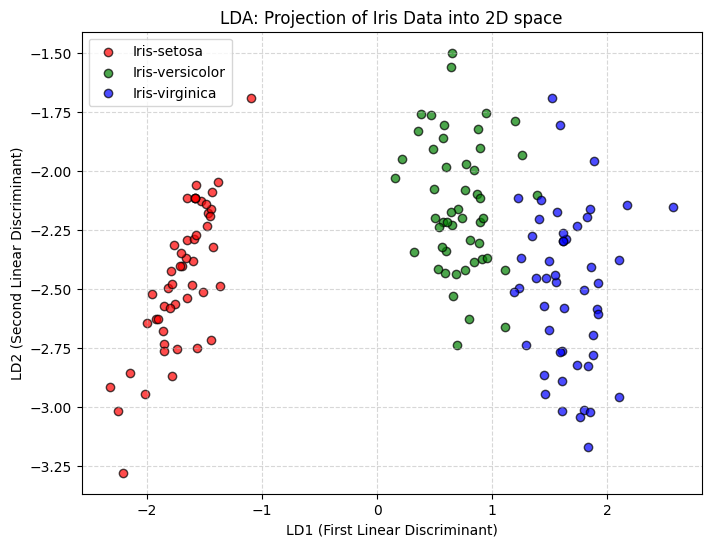

In [8]:
X_projected = X.dot(lda_multi.W)

plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']
species = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

for i, color, label in zip([0, 1, 2], colors, species):
    plt.scatter(X_projected[y == i, 0], 
                X_projected[y == i, 1], 
                color=color, 
                label=label, 
                alpha=0.7, 
                edgecolors='k')

plt.xlabel('LD1 (First Linear Discriminant)')
plt.ylabel('LD2 (Second Linear Discriminant)')
plt.title('LDA: Projection of Iris Data into 2D space')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()